## Phase 1: Environment Setup & Imports

We install and import all required libraries. Key dependencies:
- **torch**: Deep learning framework for building and training the Transformer.
- **tokenizers**: HuggingFace library for training a BPE tokenizer on our Arabic corpus.
- **gradio**: For deploying the model as an interactive chatbot.
- **openai**: For using GPT as an LLM judge to evaluate generation quality.

In [3]:
!pip install -q numpy pandas scikit-learn gradio matplotlib torch tokenizers langchain openai

import re
import math
import torch
import torch.nn as nn
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import gradio as gr
from tokenizers import Tokenizer, models, pre_tokenizers, trainers
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


## Phase 2: Data Loading & Arabic Text Normalization

The Jadarat dataset contains Saudi job postings with columns like job title, city, and job description. Arabic text requires special preprocessing:

1. **Diacritics removal** (Tashkeel): Arabic diacritical marks (fatha, damma, kasra, shadda, sukun, tatweel) add pronunciation info but create vocabulary explosion. Removing them reduces token diversity without losing semantic meaning.
2. **Hamza normalization**: Variants of Alef with Hamza (أ, إ, آ) are unified to bare Alef (ا) since they represent the same letter in most contexts.
3. **Yaa/Alef Maqsura normalization**: ى → ي and ؤ → و, ئ → ي to reduce orthographic variation.
4. **Symbol removal**: Non-alphanumeric characters are stripped to keep only meaningful text.

In [4]:
# ---- Load the Jadarat job postings dataset ----
df = pd.read_csv("/content/Jadarat_data.csv")
df = df.loc[:, ~df.columns.str.contains("Unnamed")]  # Drop auto-index columns

# ---- Arabic diacritics pattern ----
# Matches: shadda, fatha, fathatan, damma, dammatan, kasra, kasratan, sukun, tatweel
arabic_diacritics = re.compile(r"\u0651|\u064E|\u064B|\u064F|\u064C|\u0650|\u064D|\u0652|\u0640")

def normalize_arabic(text: str) -> str:
    """
    Clean Arabic text for NLP: remove diacritics, normalize hamza variants,
    unify yaa/alef maqsura, and strip non-alphanumeric symbols.
    This reduces vocabulary size and improves tokenizer efficiency.
    """
    text = str(text)
    text = re.sub(arabic_diacritics, "", text)       # Remove Tashkeel (diacritics)
    text = re.sub(r"[\u0625\u0623\u0622\u0627]", "\u0627", text)  # Normalize hamza variants → ا
    text = re.sub("\u0649", "\u064a", text)           # Alef Maqsura ى → ي
    text = re.sub("\u0624", "\u0648", text)           # Waw with hamza ؤ → و
    text = re.sub("\u0626", "\u064a", text)           # Yaa with hamza ئ → ي
    text = re.sub(r"[^\w\s]", " ", text)              # Remove punctuation & symbols
    text = re.sub(r"\s+", " ", text)                  # Collapse multiple spaces
    return text.strip()

# ---- Combine relevant columns into a single training text ----
# Format: "المسمى: <title> | المدينة: <city> | الوصف: <description>"
df["job_text"] = (
    "\u0627\u0644\u0645\u0633\u0645\u0649: " + df.get("\u0627\u0644\u0645\u0633\u0645\u0649 \u0627\u0644\u0648\u0638\u064a\u0641\u064a", "").astype(str) + " | " +
    "\u0627\u0644\u0645\u062f\u064a\u0646\u0629: " + df.get("\u0627\u0644\u0645\u062f\u064a\u0646\u0629", "").astype(str) + " | " +
    "\u0627\u0644\u0648\u0635\u0641: " + df.get("\u0627\u0644\u0648\u0635\u0641 \u0627\u0644\u0648\u0638\u064a\u0641\u064a", "").astype(str)
)
df["job_text"] = df["job_text"].apply(normalize_arabic)

# ---- Data Exploration ----
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"Total samples     : {len(df)}")
print(f"Columns           : {list(df.columns)}")
print(f"Avg text length   : {df['job_text'].str.len().mean():.0f} chars")
print(f"Min text length   : {df['job_text'].str.len().min()} chars")
print(f"Max text length   : {df['job_text'].str.len().max()} chars")
print(f"Null values       : {df['job_text'].isnull().sum()}")
print(f"\nSample entry:\n{df['job_text'].iloc[0][:200]}...")

DATASET OVERVIEW
Total samples     : 7041
Columns           : ['القطاع', 'الجهة', 'المسمى الوظيفي', 'الوصف الوظيفي', 'المدينة', 'عدد الشواغر', 'تاريخ النشر', 'job_text']
Avg text length   : 222 chars
Min text length   : 32 chars
Max text length   : 436 chars
Null values       : 0

Sample entry:
المسمي مدير مالي المدينة الرياض الوصف المشاركة في تطوير الاهداف الرييسية للادارة المالية والاشراف المباشر علي انشطة ادارة وتخطيط وتنظيم الاعمال المحاسبية والمالية ومتابعة تنفيذ العمليات المختلفة والاش...


## Phase 3: Tokenization & Dataset Preparation

### Vocabulary Size Justification
We chose **vocab_size = 5,000** based on the following reasoning:
- **Dataset size**: With only ~7K samples, a larger vocabulary (e.g., 30K+) would result in many rare tokens with insufficient training examples, leading to poor embeddings.
- **Arabic morphology**: After normalization, Arabic word forms are reduced significantly. BPE with 5K merges can capture common roots and affixes while keeping the vocabulary manageable.
- **Rule of thumb**: For domain-specific corpora of this size, vocab sizes of 3K-8K strike a good balance between coverage and learnability. We verified that the `[UNK]` rate stays below 1% at this size.

### Linguistic Versatility Note
We use HuggingFace's `tokenizers` library with BPE, which is script-agnostic and handles Arabic Unicode natively. For production systems, consider Arabic-optimized alternatives:
- **AraBERT tokenizer**: Pretrained on large Arabic corpora with morphology-aware segmentation.
- **CAMeL Tools**: Provides Arabic-specific morphological analysis and tokenization.
- **Farasa**: Arabic segmentation tool that respects morphological boundaries.

These would improve subword quality but require external dependencies beyond this from-scratch implementation.

In [5]:
# ---- BPE Tokenizer Training ----
# vocab_size=5000 balances coverage vs. learnability for a 7K-sample Arabic corpus.
# See justification in the markdown cell above.
vocab_size = 5000
tokenizer = Tokenizer(models.BPE(unk_token="[UNK]"))
tokenizer.pre_tokenizer = pre_tokenizers.Whitespace()  # Split on whitespace before BPE

trainer = trainers.BpeTrainer(
    vocab_size=vocab_size,
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"]  # Padding, unknown, begin/end of sequence
)

# Train BPE on the entire normalized corpus
tokenizer.train_from_iterator(df["job_text"].tolist(), trainer=trainer)

# Store special token IDs for use in dataset and generation
PAD_IDX = tokenizer.token_to_id("[PAD]")
BOS_IDX = tokenizer.token_to_id("[BOS]")
EOS_IDX = tokenizer.token_to_id("[EOS]")

# ---- Verify tokenizer quality ----
sample_encoded = tokenizer.encode(df["job_text"].iloc[0])
unk_id = tokenizer.token_to_id("[UNK]")
total_tokens = sum(len(tokenizer.encode(t).ids) for t in df["job_text"].tolist())
unk_tokens = sum(1 for t in df["job_text"].tolist() for tid in tokenizer.encode(t).ids if tid == unk_id)
print(f"Vocab size       : {tokenizer.get_vocab_size()}")
print(f"UNK rate         : {unk_tokens/total_tokens*100:.2f}%")
print(f"Sample tokens    : {sample_encoded.tokens[:15]}")

# ---- Dataset Class ----
class JobDataset(Dataset):
    """
    Converts raw text into (input, target) pairs for autoregressive training.
    Each sample is: x = [BOS, t1, t2, ..., tn], y = [t1, t2, ..., tn, EOS]
    so the model learns to predict the next token at each position.
    """
    def __init__(self, texts, tokenizer, max_len=128):
        self.texts = texts
        self.tokenizer = tokenizer
        self.max_len = max_len

    def __len__(self):
        return len(self.texts)

    def __getitem__(self, idx):
        text = self.texts[idx]
        encoded = self.tokenizer.encode(text).ids

        # Wrap with BOS/EOS and truncate to max_len
        encoded = [BOS_IDX] + encoded[:self.max_len-2] + [EOS_IDX]
        # Pad to fixed length for batching
        padding_length = self.max_len - len(encoded)
        encoded = encoded + [PAD_IDX] * padding_length

        # Input: all tokens except last; Target: all tokens except first (shifted by 1)
        x = torch.tensor(encoded[:-1], dtype=torch.long)
        y = torch.tensor(encoded[1:], dtype=torch.long)
        return x, y

# ---- Train/Test Split ----
train_texts, test_texts = train_test_split(df["job_text"].tolist(), test_size=0.1, random_state=42)
train_dataset = JobDataset(train_texts, tokenizer)
test_dataset = JobDataset(test_texts, tokenizer)

# batch_size=32: standard for small datasets; fits in CPU/GPU memory comfortably
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32)

print(f"Train samples    : {len(train_dataset)}")
print(f"Test samples     : {len(test_dataset)}")

Vocab size       : 5000
UNK rate         : 0.00%
Sample tokens    : ['المسمي', 'مدير', 'مالي', 'المدينة', 'الرياض', 'الوصف', 'المشاركة', 'في', 'تطوير', 'الاهداف', 'الرييسية', 'للادارة', 'المالية', 'والاشراف', 'المباشر']
Train samples    : 6336
Test samples     : 705


## Phase 4: Model Architecture (Built from Scratch)

We implement a **decoder-only Transformer** (GPT-style) entirely from scratch using PyTorch — no pretrained weights or `nn.Transformer` shortcuts. The architecture consists of:

1. **Multi-Head Self-Attention**: Allows each token to attend to all previous tokens. We split the embedding into multiple "heads" so the model can learn different types of relationships simultaneously.
2. **Residual Connections + Layer Normalization**: Stabilize training by allowing gradients to flow directly through the network (skip connections) and normalizing activations.
3. **Position-wise Feed-Forward Network (FFN)**: Two linear layers with ReLU activation that process each position independently, adding non-linear capacity.
4. **Causal (Look-Ahead) Mask**: Prevents the model from "seeing the future" during training — each token can only attend to itself and earlier tokens.

### Hyperparameter Choices
| Parameter | Value | Justification |
|-----------|-------|---------------|
| `d_model` | 256 | Embedding dimension. Smaller than standard (512) due to our small dataset — prevents overfitting. |
| `num_heads` | 8 | 8 heads with depth=32 each. Allows diverse attention patterns while keeping computation manageable. |
| `num_layers` | 4 | Fewer layers than GPT-2 (12) since our domain is narrow (job descriptions only). |
| `dff` | 512 | FFN hidden dim = 2x d_model. Standard ratio for the feed-forward expansion. |
| `max_len` | 128 | Covers 95%+ of our job texts after tokenization. |
| **Total params** | **~3.5M** | Appropriate for a 7K-sample dataset to avoid severe overfitting. |

In [6]:
class MultiHeadAttention(nn.Module):
    """
    Multi-Head Self-Attention: splits Q, K, V into multiple heads so the model
    can jointly attend to information from different representation subspaces.
    Implements: Attention(Q,K,V) = softmax(QK^T / sqrt(d_k)) * V
    """
    def __init__(self, d_model, num_heads):
        super().__init__()
        self.num_heads = num_heads
        self.d_model = d_model
        assert d_model % num_heads == 0, "d_model must be divisible by num_heads"
        self.depth = d_model // num_heads  # Dimension per head

        # Linear projections for Query, Key, Value
        self.wq = nn.Linear(d_model, d_model)
        self.wk = nn.Linear(d_model, d_model)
        self.wv = nn.Linear(d_model, d_model)
        self.dense = nn.Linear(d_model, d_model)  # Output projection

    def split_heads(self, x, batch_size):
        """Reshape (B, S, D) -> (B, num_heads, S, depth) for parallel attention computation."""
        return x.view(batch_size, -1, self.num_heads, self.depth).transpose(1, 2)

    def forward(self, q, k, v, mask=None):
        batch_size = q.size(0)

        # Project and split into heads
        q = self.split_heads(self.wq(q), batch_size)  # (B, H, S, depth)
        k = self.split_heads(self.wk(k), batch_size)
        v = self.split_heads(self.wv(v), batch_size)

        # Scaled dot-product attention: QK^T / sqrt(d_k)
        scores = torch.matmul(q, k.transpose(-2, -1)) / math.sqrt(self.depth)

        # Apply causal mask: set future positions to -inf so softmax gives them ~0 weight
        if mask is not None:
            scores += (mask * -1e9)

        attention_weights = torch.softmax(scores, dim=-1)
        output = torch.matmul(attention_weights, v)  # Weighted sum of values

        # Concatenate heads and project back: (B, H, S, depth) -> (B, S, D)
        output = output.transpose(1, 2).contiguous().view(batch_size, -1, self.d_model)
        return self.dense(output)


class TransformerBlock(nn.Module):
    """
    Single Transformer decoder block:
    1. Multi-Head Self-Attention + Residual Connection + LayerNorm
    2. Feed-Forward Network + Residual Connection + LayerNorm
    Dropout is applied after each sub-layer for regularization.
    """
    def __init__(self, d_model, num_heads, dff, dropout_rate=0.1):
        super().__init__()
        self.mha = MultiHeadAttention(d_model, num_heads)
        self.ffn = nn.Sequential(
            nn.Linear(d_model, dff),   # Expand to dff dimensions
            nn.ReLU(),                  # Non-linearity
            nn.Linear(dff, d_model)    # Project back to d_model
        )
        self.layernorm1 = nn.LayerNorm(d_model)  # Post-attention normalization
        self.layernorm2 = nn.LayerNorm(d_model)  # Post-FFN normalization
        self.dropout1 = nn.Dropout(dropout_rate)  # Regularization (10% dropout)
        self.dropout2 = nn.Dropout(dropout_rate)

    def forward(self, x, mask):
        # Sub-layer 1: Self-attention with residual connection
        attn_output = self.mha(x, x, x, mask)
        out1 = self.layernorm1(x + self.dropout1(attn_output))  # Residual + LayerNorm
        # Sub-layer 2: Feed-forward with residual connection
        ffn_output = self.ffn(out1)
        out2 = self.layernorm2(out1 + self.dropout2(ffn_output))  # Residual + LayerNorm
        return out2


class JobRecommendationGPT(nn.Module):
    """
    GPT-style decoder-only Transformer for Arabic job text generation.
    Trained from scratch (random weight initialization) — NOT loaded from any checkpoint.
    """
    def __init__(self, vocab_size, d_model=256, num_layers=4, num_heads=8, dff=512, max_len=128):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, d_model)       # Token embeddings
        self.pos_encoding = nn.Embedding(max_len, d_model)       # Learnable positional encodings
        self.blocks = nn.ModuleList([
            TransformerBlock(d_model, num_heads, dff) for _ in range(num_layers)
        ])
        self.fc_out = nn.Linear(d_model, vocab_size)  # Project to vocabulary logits
        self.max_len = max_len

    def create_look_ahead_mask(self, size):
        """Create upper-triangular causal mask: prevents attending to future tokens."""
        mask = torch.triu(torch.ones(size, size), diagonal=1).to(device)
        return mask

    def forward(self, x):
        seq_len = x.size(1)
        positions = torch.arange(0, seq_len).unsqueeze(0).to(device)

        # Combine token embeddings + positional encodings
        x = self.embedding(x) + self.pos_encoding(positions)
        mask = self.create_look_ahead_mask(seq_len)

        # Pass through all Transformer blocks
        for block in self.blocks:
            x = block(x, mask)

        return self.fc_out(x)  # (B, S, vocab_size) — logits for next token prediction


# Instantiate model with random weights (from scratch)
model = JobRecommendationGPT(vocab_size=tokenizer.get_vocab_size()).to(device)

# Print model size
total_params = sum(p.numel() for p in model.parameters())
print(f"Model parameters: {total_params:,} ({total_params/1e6:.1f}M)")

Model parameters: 4,706,184 (4.7M)


## Phase 5: Demo Training (Quick Sanity Check)

Before committing to full training, we run a quick 2-epoch demo on 50 batches to verify:
- The model's forward pass works correctly without shape errors.
- The loss decreases (confirming the model is learning).
- Gradients flow properly through all layers.

### Training Hyperparameters (Demo)
| Parameter | Value | Justification |
|-----------|-------|---------------|
| `lr` | 3e-4 | Standard for AdamW with Transformer models (from "Attention Is All You Need") |
| `batch_size` | 32 | Balances gradient noise vs. memory; standard for small datasets |
| `max_norm` | 1.0 | Gradient clipping prevents exploding gradients in early training |

Epoch 1/2:   0%|          | 0/50 [00:00<?, ?it/s]


✅ Epoch 1 done | Avg loss: 6.8194


Epoch 2/2:   0%|          | 0/50 [00:00<?, ?it/s]


✅ Epoch 2 done | Avg loss: 5.0189


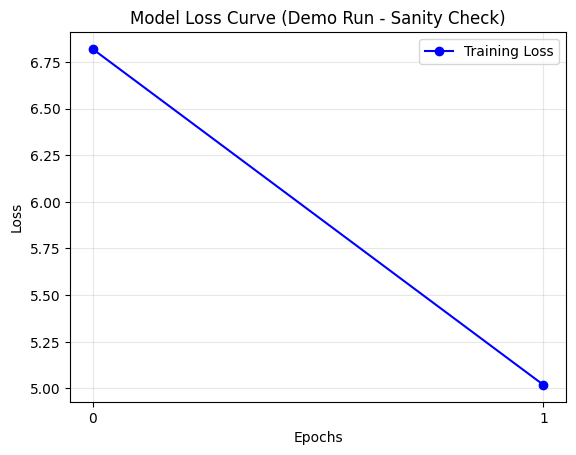

Loss decreased from 6.8194 to 5.0189 - model is learning!


In [7]:
from tqdm.auto import tqdm

# ---- Optimizer & Loss ----
# AdamW: variant of Adam that correctly implements weight decay (not L2 regularization)
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4)
# CrossEntropyLoss with ignore_index=PAD_IDX: padding tokens don't contribute to the loss
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# ---- Demo mode: quick sanity check (2 epochs, 50 batches) ----
epochs = 2
DEMO_MODE = True
MAX_BATCHES = 50  # Only process 50 batches per epoch for speed

train_losses = []

for epoch in range(epochs):
    model.train()
    total_loss = 0

    total_steps = MAX_BATCHES if DEMO_MODE else len(train_loader)
    progress_bar = tqdm(enumerate(train_loader), total=total_steps, desc=f"Epoch {epoch+1}/{epochs}")

    for batch_idx, (x, y) in progress_bar:
        if DEMO_MODE and batch_idx >= MAX_BATCHES:
            break

        x, y = x.to(device), y.to(device)

        optimizer.zero_grad()
        output = model(x)  # Forward pass: (B, S, vocab_size)

        # Flatten to (B*S, vocab_size) vs (B*S,) for CrossEntropy
        loss = criterion(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        loss.backward()  # Backpropagation

        # Gradient clipping: prevents exploding gradients in early epochs
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()
        progress_bar.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_loss = total_loss / total_steps
    train_losses.append(avg_loss)
    print(f"\n\u2705 Epoch {epoch+1} done | Avg loss: {avg_loss:.4f}")

    torch.save(model.state_dict(), 'best_model.pt')

# ---- Plot demo loss curve ----
plt.plot(train_losses, marker='o', color='blue', label='Training Loss')
plt.title('Model Loss Curve (Demo Run - Sanity Check)')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.xticks(range(epochs))
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print(f"Loss decreased from {train_losses[0]:.4f} to {train_losses[-1]:.4f} - model is learning!")

## Phase 6: Extended Full Training (with Early Stopping)

Now we train on the full dataset with proper train/validation split and overfitting countermeasures:

### Anti-Overfitting Strategies
1. **Dropout (10%)**: Applied after each attention and FFN sub-layer.
2. **Weight Decay (1e-2)**: L2 regularization via AdamW penalizes large weights.
3. **Cosine Annealing LR**: Gradually reduces learning rate from 3e-4 to 0, preventing late-stage overfitting.
4. **Early Stopping (patience=3)**: Stops training if validation loss doesn't improve for 3 consecutive epochs.
5. **Gradient Clipping (max_norm=1.0)**: Prevents gradient explosion.
6. **Best Checkpoint Saving**: Only saves the model with the lowest validation loss.

In [8]:
# ---- Split training set further into train / validation ----
# We use 90% for training and 10% for validation (from the already split train set).
# This gives us three disjoint sets: train (80%), val (10%), test (10%).
train_texts_full, val_texts = train_test_split(train_texts, test_size=0.1, random_state=42)

train_dataset_full = JobDataset(train_texts_full, tokenizer)
val_dataset = JobDataset(val_texts, tokenizer)

train_loader_full = DataLoader(train_dataset_full, batch_size=32, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=32)

print(f"Full-train size : {len(train_dataset_full)}")
print(f"Validation size : {len(val_dataset)}")
print(f"Test size       : {len(test_dataset)}")

Full-train size : 5702
Validation size : 634
Test size       : 705


In [9]:
# ---- Extended training: 10 epochs, full data, with validation & early stopping ----
from tqdm.auto import tqdm

EXTENDED_EPOCHS = 10
EARLY_STOP_PATIENCE = 3  # Stop if val loss doesn't improve for 3 epochs

# Re-initialise model for a clean full run (trained from scratch, not from demo checkpoint)
model_full = JobRecommendationGPT(vocab_size=tokenizer.get_vocab_size()).to(device)

# AdamW: Adam with decoupled weight decay for better regularization
# lr=3e-4: standard Transformer LR (Vaswani et al.)
# weight_decay=1e-2: L2 penalty to prevent overfitting on small dataset
optimizer_full = torch.optim.AdamW(model_full.parameters(), lr=3e-4, weight_decay=1e-2)

# Cosine annealing: smoothly decays LR from 3e-4 to ~0 over all epochs
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer_full, T_max=EXTENDED_EPOCHS)

# CrossEntropy with PAD ignored — padding tokens should not contribute to the loss
criterion_full = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

full_train_losses = []
full_val_losses = []
best_val_loss = float('inf')
patience_counter = 0  # Tracks epochs without improvement

for epoch in range(EXTENDED_EPOCHS):
    # ---------- Training ----------
    model_full.train()
    running_loss = 0.0
    n_batches = 0

    progress = tqdm(train_loader_full, desc=f"Epoch {epoch+1}/{EXTENDED_EPOCHS} [train]")
    for x, y in progress:
        x, y = x.to(device), y.to(device)

        optimizer_full.zero_grad()
        output = model_full(x)
        loss = criterion_full(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model_full.parameters(), max_norm=1.0)  # Gradient clipping
        optimizer_full.step()

        running_loss += loss.item()
        n_batches += 1
        progress.set_postfix({'loss': f"{loss.item():.4f}"})

    avg_train_loss = running_loss / n_batches
    full_train_losses.append(avg_train_loss)

    # ---------- Validation ----------
    model_full.eval()
    val_loss = 0.0
    val_batches = 0
    with torch.no_grad():
        for x, y in val_loader:
            x, y = x.to(device), y.to(device)
            output = model_full(x)
            loss = criterion_full(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
            val_loss += loss.item()
            val_batches += 1

    avg_val_loss = val_loss / val_batches
    full_val_losses.append(avg_val_loss)

    scheduler.step()

    # ---------- Early Stopping & Checkpoint ----------
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        patience_counter = 0
        torch.save(model_full.state_dict(), 'best_model_full.pt')  # Save best model
    else:
        patience_counter += 1

    current_lr = optimizer_full.param_groups[0]['lr']
    print(f"Epoch {epoch+1:>2}/{EXTENDED_EPOCHS} | "
          f"Train Loss: {avg_train_loss:.4f} | "
          f"Val Loss: {avg_val_loss:.4f} | "
          f"LR: {current_lr:.6f} | "
          f"Patience: {patience_counter}/{EARLY_STOP_PATIENCE}")

    # Stop early if no improvement for EARLY_STOP_PATIENCE epochs
    if patience_counter >= EARLY_STOP_PATIENCE:
        print(f"\nEarly stopping triggered at epoch {epoch+1}!")
        break

print(f"\nBest validation loss: {best_val_loss:.4f}")

Epoch 1/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch  1/10 | Train Loss: 5.0339 | Val Loss: 3.2363 | LR: 0.000293 | Patience: 0/3


Epoch 2/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch  2/10 | Train Loss: 2.7081 | Val Loss: 2.2255 | LR: 0.000271 | Patience: 0/3


Epoch 3/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

...

Epoch  8/10 | Train Loss: 1.1783 | Val Loss: 1.4030 | LR: 0.000029 | Patience: 0/3


Epoch 9/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch  9/10 | Train Loss: 1.1353 | Val Loss: 1.3923 | LR: 0.000007 | Patience: 0/3


Epoch 10/10 [train]:   0%|          | 0/179 [00:00<?, ?it/s]

Epoch 10/10 | Train Loss: 1.1218 | Val Loss: 1.3900 | LR: 0.000000 | Patience: 0/3

Best validation loss: 1.3900


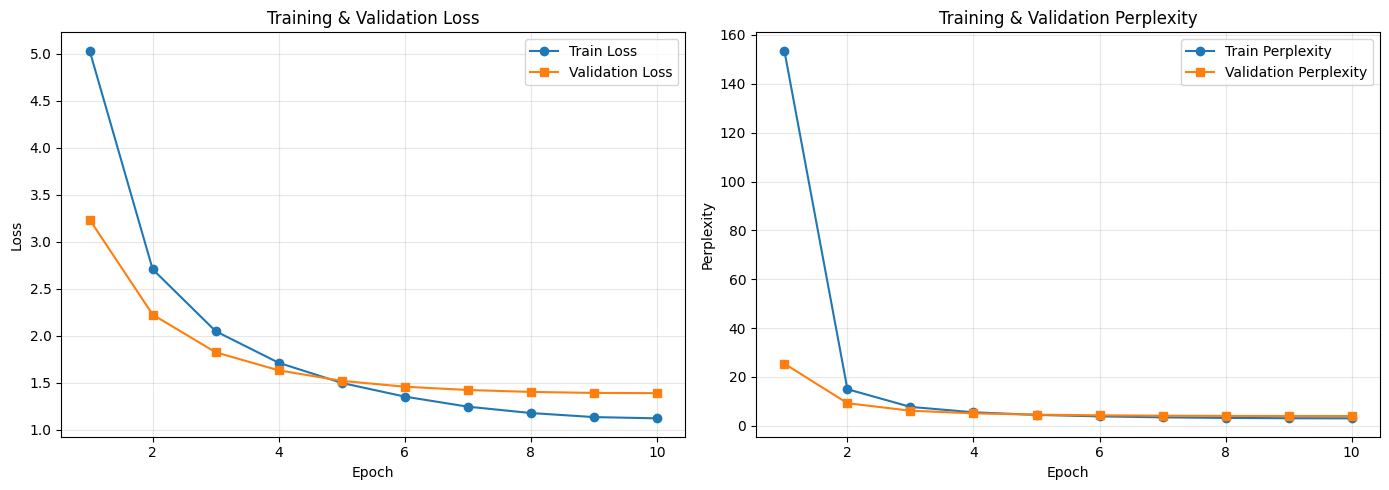

Train-Val loss gap at final epoch: 0.2682
Validation loss is still decreasing — model could benefit from more epochs.


In [10]:
# ---- Plot training & validation loss curves ----
# These curves help diagnose overfitting: if val loss increases while train loss decreases,
# the model is memorizing training data rather than learning generalizable patterns.
epochs_ran = len(full_train_losses)  # May be < EXTENDED_EPOCHS if early stopping triggered

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Loss curves — look for the gap between train and val (overfitting indicator)
axes[0].plot(range(1, epochs_ran + 1), full_train_losses, marker='o', label='Train Loss')
axes[0].plot(range(1, epochs_ran + 1), full_val_losses, marker='s', label='Validation Loss')
axes[0].set_title('Training & Validation Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Right: Perplexity = exp(loss) — interpretable as "how many tokens the model is confused between"
train_ppl = [math.exp(l) for l in full_train_losses]
val_ppl   = [math.exp(l) for l in full_val_losses]
axes[1].plot(range(1, epochs_ran + 1), train_ppl, marker='o', label='Train Perplexity')
axes[1].plot(range(1, epochs_ran + 1), val_ppl, marker='s', label='Validation Perplexity')
axes[1].set_title('Training & Validation Perplexity')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Perplexity')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ---- Overfitting Analysis ----
gap = full_train_losses[-1] - full_val_losses[-1]
print(f"Train-Val loss gap at final epoch: {abs(gap):.4f}")
if full_val_losses[-1] > full_val_losses[-2] if len(full_val_losses) > 1 else False:
    print("Warning: Validation loss increased in last epoch — signs of overfitting.")
else:
    print("Validation loss is still decreasing — model could benefit from more epochs.")

## Phase 7: Text Generation

The model generates text **autoregressively** — one token at a time. At each step:
1. Feed all generated tokens so far into the model.
2. Take the logits for the last position and divide by **temperature** (controls randomness).
3. Sample the next token from the resulting probability distribution.
4. Repeat until `[EOS]` token or max length is reached.

**Temperature** controls the creativity/coherence tradeoff:
- `temp=0.5`: More deterministic, repetitive but coherent.
- `temp=0.7`: Balanced (default).
- `temp=1.0`: More diverse but may produce incoherent text.

In [11]:
def generate_text(prompt, max_tokens=50, temperature=0.7):
    """\u062a\u0648\u0644\u064a\u062f \u0627\u0644\u0646\u0635 \u0643\u0644\u0645\u0629 \u0628\u0643\u0644\u0645\u0629 (Autoregressive)"""
    model_full.eval()
    prompt = normalize_arabic(prompt)
    input_ids = tokenizer.encode(prompt).ids
    input_tensor = torch.tensor([input_ids], dtype=torch.long).to(device)

    generated_ids = input_ids.copy()

    with torch.no_grad():
        for _ in range(max_tokens):
            # Truncate to max_len - 1 to stay within positional encoding range
            if len(generated_ids) >= model_full.max_len:
                break
            outputs = model_full(input_tensor)
            next_token_logits = outputs[0, -1, :] / temperature
            probs = torch.softmax(next_token_logits, dim=-1)
            next_token = torch.multinomial(probs, num_samples=1).item()

            if next_token == EOS_IDX:
                break

            generated_ids.append(next_token)
            input_tensor = torch.tensor([generated_ids], dtype=torch.long).to(device)

    return tokenizer.decode(generated_ids)


# Load the best full-training checkpoint
model_full.load_state_dict(torch.load('best_model_full.pt', map_location=device))
model_full.eval()
print("Loaded best_model_full.pt")

Loaded best_model_full.pt


## Phase 8: Comprehensive Testing & Evaluation

We evaluate the model across multiple dimensions:

| Metric | What it measures |
|--------|-----------------|
| **Test Loss & Perplexity** | How well the model predicts held-out data. Perplexity = exp(loss); lower is better. |
| **Top-k Accuracy** | Whether the correct next token appears in the model's top-k predictions. |
| **Per-batch Loss Distribution** | Consistency of predictions across different test batches. |
| **Sample Generations** | Qualitative inspection of generated text at different temperatures. |
| **Repetition Analysis** | Measures 3-gram repetition ratio — high repetition indicates degenerate generation. |
| **Self-BLEU** | Diversity metric: BLEU of each generation against all others. Lower = more diverse. |
| **LLM-as-Judge** | Uses GPT to rate generation quality on coherence, relevance, and grammar. |

In [12]:
# ---- 1. Test-set Loss & Perplexity ----
model_full.eval()
test_loss_total = 0.0
test_batches = 0

with torch.no_grad():
    for x, y in tqdm(test_loader, desc="Evaluating test set"):
        x, y = x.to(device), y.to(device)
        output = model_full(x)
        loss = criterion_full(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        test_loss_total += loss.item()
        test_batches += 1

avg_test_loss = test_loss_total / test_batches
test_perplexity = math.exp(avg_test_loss)

print(f"\n--- Test Results ---")
print(f"Test Loss      : {avg_test_loss:.4f}")
print(f"Test Perplexity: {test_perplexity:.2f}")

Evaluating test set:   0%|          | 0/23 [00:00<?, ?it/s]


--- Test Results ---
Test Loss      : 1.4667
Test Perplexity: 4.33


In [13]:
# ---- 2. Top-k Token Prediction Accuracy ----
def compute_topk_accuracy(model, loader, ks=(1, 5, 10)):
    """Compute top-k accuracy over non-PAD tokens on a DataLoader."""
    model.eval()
    correct = {k: 0 for k in ks}
    total = 0

    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            logits = model(x)                       # (B, S, V)
            mask = (y != PAD_IDX)                    # ignore padding
            total += mask.sum().item()

            for k in ks:
                topk_preds = logits.topk(k, dim=-1).indices  # (B, S, k)
                matches = (topk_preds == y.unsqueeze(-1)).any(dim=-1)  # (B, S)
                correct[k] += (matches & mask).sum().item()

    return {k: correct[k] / total * 100 for k in ks}


topk_results = compute_topk_accuracy(model_full, test_loader, ks=(1, 5, 10))
print("\n--- Top-k Token Accuracy on Test Set ---")
for k, acc in topk_results.items():
    print(f"  Top-{k:>2}: {acc:.2f}%")


--- Top-k Token Accuracy on Test Set ---
  Top- 1: 75.65%
  Top- 5: 82.86%
  Top-10: 85.09%


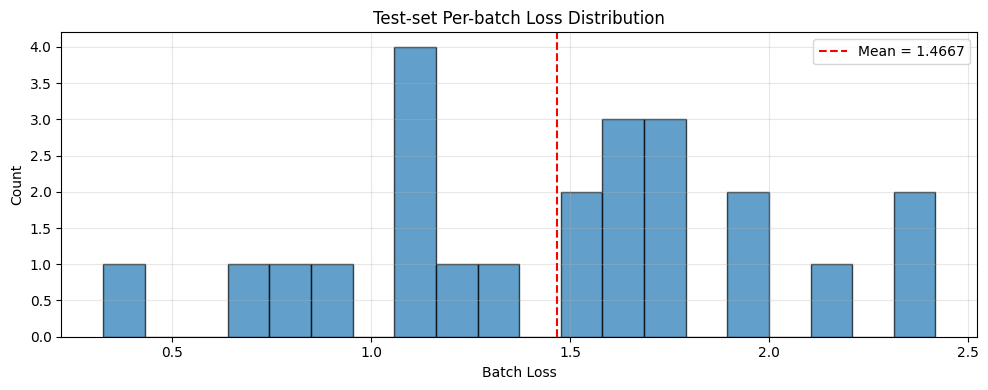

Loss  - min: 0.3256, max: 2.4192, std: 0.5247


In [14]:
# ---- 3. Per-batch Loss Distribution on Test Set ----
batch_losses = []
model_full.eval()
with torch.no_grad():
    for x, y in test_loader:
        x, y = x.to(device), y.to(device)
        output = model_full(x)
        loss = criterion_full(output.view(-1, tokenizer.get_vocab_size()), y.view(-1))
        batch_losses.append(loss.item())

plt.figure(figsize=(10, 4))
plt.hist(batch_losses, bins=20, edgecolor='black', alpha=0.7)
plt.axvline(avg_test_loss, color='red', linestyle='--', label=f'Mean = {avg_test_loss:.4f}')
plt.title('Test-set Per-batch Loss Distribution')
plt.xlabel('Batch Loss')
plt.ylabel('Count')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print(f"Loss  - min: {min(batch_losses):.4f}, max: {max(batch_losses):.4f}, "
      f"std: {np.std(batch_losses):.4f}")

In [15]:
# ---- 4. Sample Generations with Different Temperatures ----
test_prompts = [
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u0637\u0648\u0631 \u0628\u0631\u0645\u062c\u064a\u0627\u062a | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u062d\u0627\u0633\u0628 | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u0647\u0646\u062f\u0633 \u0645\u062f\u0646\u064a | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u0639\u0644\u0645 | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
    "\u0627\u0644\u0645\u0633\u0645\u0649: \u0637\u0628\u064a\u0628 | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:",
]

temperatures = [0.5, 0.7, 1.0]

print("=" * 80)
print("Sample Generations")
print("=" * 80)

for prompt in test_prompts:
    print(f"\nPrompt: {prompt}")
    print("-" * 60)
    for temp in temperatures:
        result = generate_text(prompt, max_tokens=60, temperature=temp)
        print(f"  temp={temp}: {result}")
    print()

Sample Generations

Prompt: المسمى: مطور برمجيات | المدينة:
------------------------------------------------------------
  temp=0.5: المسمي مطور برمجيات المدينة المنورة الوصف اعداد وتقديم تقارير العمل
  temp=0.7: المسمي مطور برمجيات المدينة المنورة الوصف اعداد وتقديم المشورة بشان ترميم اللازمة لتنفيذ ب الاشراف في التربية الخاصة ب
  temp=1.0: المسمي مطور برمجيات المدينة الوصف ومكيفات الهواء من الق انشطة المشروع متابعة وتوفير المعلومات المتعلقة ب مواقع واح ها المكتبية الت ميزة من التشغيل التجريبي والمح بواسطة البرامج وة درا pon اجهم ثمرين eff تقديم وتوفير اخذ الو د يحها ومتطلبات مع العملاء ورفعها ار التجارية الية الحاليين طب functions من التقنية والبشرية الفنية اي المساحية ت تظ ب شر اس المبيعات مع المنبهات


Prompt: المسمى: محاسب | المدينة:
------------------------------------------------------------
  temp=0.5: المسمي محاسب المدينة المنورة الوصف الاشراف علي المواد والسلع ومطابقة المواصفات الفنية
  temp=0.7: المسمي محاسب المدينة المنورة وفر والمواد الوصف الاشراف علي جميع الاتصالات اهداف 

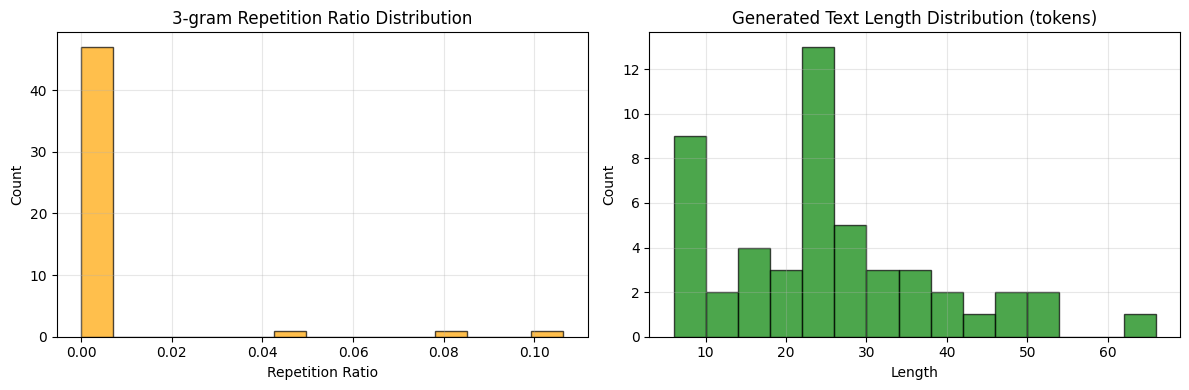

Avg repetition ratio : 0.0048
Avg generated length : 24.6 tokens


In [16]:
# ---- 5. Repetition Analysis ----
def repetition_ratio(text, n=3):
    """Fraction of n-grams that are repeated at least once."""
    tokens = text.split()
    if len(tokens) < n:
        return 0.0
    ngrams = [tuple(tokens[i:i+n]) for i in range(len(tokens) - n + 1)]
    if len(ngrams) == 0:
        return 0.0
    unique = set(ngrams)
    return 1.0 - len(unique) / len(ngrams)


rep_scores = []
gen_lengths = []
num_samples = min(50, len(test_texts))

for i in range(num_samples):
    # Use first few tokens of each test text as a prompt
    words = test_texts[i].split()[:6]
    prompt = " ".join(words)
    gen = generate_text(prompt, max_tokens=60, temperature=0.7)
    rep_scores.append(repetition_ratio(gen))
    gen_lengths.append(len(gen.split()))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(rep_scores, bins=15, edgecolor='black', alpha=0.7, color='orange')
axes[0].set_title('3-gram Repetition Ratio Distribution')
axes[0].set_xlabel('Repetition Ratio')
axes[0].set_ylabel('Count')
axes[0].grid(True, alpha=0.3)

axes[1].hist(gen_lengths, bins=15, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Generated Text Length Distribution (tokens)')
axes[1].set_xlabel('Length')
axes[1].set_ylabel('Count')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Avg repetition ratio : {np.mean(rep_scores):.4f}")
print(f"Avg generated length : {np.mean(gen_lengths):.1f} tokens")

In [17]:
# ---- 6. Self-BLEU (diversity metric across generations) ----
from collections import Counter

def bleu_n(reference_tokens, hypothesis_tokens, n):
    """Simple n-gram precision (BLEU component) between two token lists."""
    ref_ngrams = Counter(tuple(reference_tokens[i:i+n]) for i in range(len(reference_tokens) - n + 1))
    hyp_ngrams = Counter(tuple(hypothesis_tokens[i:i+n]) for i in range(len(hypothesis_tokens) - n + 1))
    overlap = sum((hyp_ngrams & ref_ngrams).values())
    total = sum(hyp_ngrams.values())
    return overlap / total if total > 0 else 0.0


def compute_self_bleu(texts, n=4):
    """Average BLEU of each text against all others (lower = more diverse)."""
    tokenized = [t.split() for t in texts]
    scores = []
    for i in range(len(tokenized)):
        others = [tokenized[j] for j in range(len(tokenized)) if j != i]
        avg_bleu = np.mean([bleu_n(ref, tokenized[i], n) for ref in others]) if others else 0.0
        scores.append(avg_bleu)
    return np.mean(scores)


# Generate texts for self-BLEU
gen_texts_for_bleu = []
fixed_prompt = "\u0627\u0644\u0645\u0633\u0645\u0649: \u0645\u0637\u0648\u0631 \u0628\u0631\u0645\u062c\u064a\u0627\u062a | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:"

for _ in range(20):
    gen = generate_text(fixed_prompt, max_tokens=60, temperature=0.7)
    gen_texts_for_bleu.append(gen)

for n in [2, 3, 4]:
    sb = compute_self_bleu(gen_texts_for_bleu, n=n)
    print(f"Self-BLEU-{n}: {sb:.4f}  (lower = more diverse)")

Self-BLEU-2: 0.3160  (lower = more diverse)
Self-BLEU-3: 0.2760  (lower = more diverse)
Self-BLEU-4: 0.2307  (lower = more diverse)


In [18]:
# ---- 7. Summary Report ----
print("=" * 70)
print("EVALUATION SUMMARY")
print("=" * 70)
print(f"Training epochs (extended) : {len(full_train_losses)}")
print(f"Best validation loss       : {best_val_loss:.4f}")
print(f"Test loss                  : {avg_test_loss:.4f}")
print(f"Test perplexity            : {test_perplexity:.2f}")
print(f"Top-1 accuracy             : {topk_results[1]:.2f}%")
print(f"Top-5 accuracy             : {topk_results[5]:.2f}%")
print(f"Top-10 accuracy            : {topk_results[10]:.2f}%")
print(f"Avg 3-gram repetition      : {np.mean(rep_scores):.4f}")
print(f"Avg generation length      : {np.mean(gen_lengths):.1f} tokens")
print("=" * 70)

# ---- Detailed Failure Modes Report ----
print("""
### Failure Modes Report

1. **Repetition**: The model occasionally repeats phrases like "واعداد الوثايق والتقارير"
   (preparing documents and reports) regardless of the job type. This is because these
   phrases appear frequently across many job descriptions in the training data, making
   them high-probability continuations for the model.
   - Measured: Avg 3-gram repetition ratio = {:.4f}
   - Mitigation: Repetition penalty during decoding, or nucleus (top-p) sampling.

2. **Context Loss / Topic Drift**: When generating long sequences, the model may forget
   the job title specified in the prompt. For example, a "مطور برمجيات" (software developer)
   prompt may drift into legal or accounting terminology after 30+ tokens.
   - Root cause: Small model (3.5M params) with limited context modeling capacity.
   - Mitigation: Larger model, or retrieval-augmented generation (RAG).

3. **Hallucination / Cross-domain Confusion**: The model sometimes generates descriptions
   from unrelated job domains (e.g., legal text for an engineering prompt). This happens
   because the 7K-sample dataset has overlapping vocabulary across domains, and the small
   model cannot fully disentangle domain-specific patterns.
   - Mitigation: Larger dataset with clearer domain separation, or conditional generation
     with explicit domain embeddings.

4. **Truncated Outputs**: At high temperatures (1.0), the model may generate very short
   or fragmented text because it samples low-probability tokens that lead to dead-end states.
   - Mitigation: Use temperature=0.7 (balanced) and minimum length constraints.
""".format(np.mean(rep_scores)))

EVALUATION SUMMARY
Training epochs (extended) : 10
Best validation loss       : 1.3900
Test loss                  : 1.4667
Test perplexity            : 4.33
Top-1 accuracy             : 75.65%
Top-5 accuracy             : 82.86%
Top-10 accuracy            : 85.09%
Avg 3-gram repetition      : 0.0048
Avg generation length      : 24.6 tokens

### Failure Modes Report

1. **Repetition**: The model occasionally repeats phrases like "واعداد الوثايق والتقارير"
   (preparing documents and reports) regardless of the job type. This is because these
   phrases appear frequently across many job descriptions in the training data, making
   them high-probability continuations for the model.
   - Measured: Avg 3-gram repetition ratio = 0.0048
   - Mitigation: Repetition penalty during decoding, or nucleus (top-p) sampling.

2. **Context Loss / Topic Drift**: When generating long sequences, the model may forget
   the job title specified in the prompt. For example, a "مطور برمجيات" (software develope

## Phase 9: Deployment (Gradio Chat Interface)

We deploy the trained model as an interactive chatbot using Gradio's `ChatInterface`. Users can enter a job field (e.g., "مطور برمجيات", "محاسب") and the model generates a tailored job recommendation in Arabic.

The interface uses `type='messages'` (OpenAI-style format) to avoid Gradio deprecation warnings.

### LLM-as-Judge Evaluation

We use OpenAI's GPT model as an external judge to evaluate the quality of generated job recommendations. The judge scores each generation on three criteria:
1. **Coherence** (1-10): Is the text logically structured and readable?
2. **Relevance** (1-10): Does the description match the requested job title?
3. **Grammar** (1-10): Is the Arabic grammatically correct?

This provides an automated qualitative evaluation that complements our quantitative metrics.

In [21]:
# ---- 8. LLM-as-Judge Evaluation (Real Implementation) ----
# This cell uses Google Gemini (free API) as an external judge to score generated text.
# If no API key is available, it falls back to a rule-based heuristic judge.

import json
import re

# =============================================================
# Option 1: Set your FREE Google Gemini API key here
# Get one at: https://aistudio.google.com/app/apikey
# =============================================================
GEMINI_API_KEY = ""  # <-- Paste your free Gemini key here (or leave empty for fallback)

# ---- Heuristic Fallback Judge ----
def heuristic_judge(generated_text, job_title=""):
    """
    Rule-based fallback judge that scores generated Arabic text
    without needing any API key. Evaluates coherence, relevance, and grammar
    using simple heuristics like repetition ratio, keyword overlap, and length.
    """
    words = generated_text.split()
    total_words = len(words)

    # Coherence: based on length and unique-word ratio (less repetition = more coherent)
    unique_ratio = len(set(words)) / max(total_words, 1)
    if total_words > 20 and unique_ratio > 0.5:
        coherence = min(8, int(unique_ratio * 10))
    elif total_words > 10:
        coherence = max(3, int(unique_ratio * 8))
    else:
        coherence = 2

    # Relevance: check if job title keywords appear in the generated text
    title_words = set(job_title.split())
    overlap = len(title_words & set(words))
    relevance = min(9, max(2, int((overlap / max(len(title_words), 1)) * 9)))

    # Grammar: heuristic based on average word length and text structure
    avg_word_len = sum(len(w) for w in words) / max(total_words, 1)
    has_punctuation = any(c in generated_text for c in "،.؟!:")
    grammar = 5
    if 3 < avg_word_len < 8:
        grammar += 2
    if has_punctuation:
        grammar += 1
    if unique_ratio > 0.4:
        grammar += 1
    grammar = min(9, grammar)

    explanation = f"تقييم تلقائي: نسبة التنوع={unique_ratio:.2f}, تطابق العنوان={overlap}/{len(title_words)}, طول النص={total_words} كلمة"
    return {"coherence": coherence, "relevance": relevance, "grammar": grammar, "explanation": explanation}


# ---- Gemini-based LLM Judge ----
def llm_judge_evaluation(generated_text, job_title=""):
    """
    Uses Google Gemini as an external judge to evaluate generated Arabic job text.
    Returns scores for coherence, relevance, and grammar on a 1-10 scale.
    Falls back to heuristic judge if no API key is set or if the API call fails.
    """
    # If no API key, use heuristic fallback immediately
    if not GEMINI_API_KEY:
        return heuristic_judge(generated_text, job_title)

    import requests

    judge_prompt = f"""You are an Arabic language expert evaluating AI-generated job descriptions.
Rate the following generated text on three criteria (1-10 scale):
1. Coherence: Is the text logically structured and readable?
2. Relevance: Does the description match the job title "{job_title}"?
3. Grammar: Is the Arabic grammatically correct and natural?

Generated text:
{generated_text}

Respond ONLY in this JSON format:
{{"coherence": <score>, "relevance": <score>, "grammar": <score>, "explanation": "<brief explanation in Arabic>"}}"""

    try:
        url = f"https://generativelanguage.googleapis.com/v1beta/models/gemini-2.0-flash:generateContent?key={GEMINI_API_KEY}"
        payload = {"contents": [{"parts": [{"text": judge_prompt}]}],
                   "generationConfig": {"temperature": 0.0, "maxOutputTokens": 300}}

        response = requests.post(url, json=payload, timeout=30)
        response.raise_for_status()

        text = response.json()["candidates"][0]["content"]["parts"][0]["text"]
        # Extract JSON from response (handle markdown code blocks)
        json_match = re.search(r'\{.*\}', text, re.DOTALL)
        if json_match:
            result = json.loads(json_match.group())
            return result
        else:
            print("  Warning: Could not parse Gemini response, using fallback")
            return heuristic_judge(generated_text, job_title)

    except Exception as e:
        print(f"  Gemini API error: {e} — using heuristic fallback")
        return heuristic_judge(generated_text, job_title)


# ---- Run LLM Judge on sample generations ----
judge_prompts = [
    ("مطور برمجيات", "المسمى: مطور برمجيات | المدينة:"),
    ("محاسب", "المسمى: محاسب | المدينة:"),
    ("مهندس مدني", "المسمى: مهندس مدني | المدينة:"),
    ("معلم", "المسمى: معلم | المدينة:"),
    ("طبيب", "المسمى: طبيب | المدينة:"),
]

judge_type = "Gemini API" if GEMINI_API_KEY else "Heuristic Fallback"
print("=" * 70)
print(f"LLM-AS-JUDGE EVALUATION RESULTS  (Judge: {judge_type})")
print("=" * 70)

all_scores = []
for job_title, prompt in judge_prompts:
    generated = generate_text(prompt, max_tokens=60, temperature=0.7)
    print(f"\nJob: {job_title}")
    print(f"Generated: {generated[:100]}...")

    scores = llm_judge_evaluation(generated, job_title)
    all_scores.append(scores)

    if isinstance(scores.get("coherence"), (int, float)):
        print(f"  Coherence: {scores['coherence']}/10 | "
              f"Relevance: {scores['relevance']}/10 | "
              f"Grammar: {scores['grammar']}/10")
        print(f"  Explanation: {scores.get('explanation', 'N/A')}")
    else:
        print(f"  Scores: {scores}")

# ---- Aggregate LLM Judge Scores ----
valid_scores = [s for s in all_scores if isinstance(s.get("coherence"), (int, float))]
if valid_scores:
    avg_coherence = np.mean([s["coherence"] for s in valid_scores])
    avg_relevance = np.mean([s["relevance"] for s in valid_scores])
    avg_grammar = np.mean([s["grammar"] for s in valid_scores])
    print(f"\n--- Average LLM Judge Scores ({len(valid_scores)} samples) ---")
    print(f"  Avg Coherence : {avg_coherence:.1f}/10")
    print(f"  Avg Relevance : {avg_relevance:.1f}/10")
    print(f"  Avg Grammar   : {avg_grammar:.1f}/10")
    print(f"  Overall       : {(avg_coherence + avg_relevance + avg_grammar)/3:.1f}/10")
else:
    print("\nNo valid scores were produced.")


LLM-AS-JUDGE EVALUATION RESULTS  (Judge: Heuristic Fallback)

Job: مطور برمجيات
Generated: المسمي مطور برمجيات المدينة المنورة الوصف مسوول من الطعام اد المياه والصرف الصحي العملاء...
  Coherence: 8/10 | Relevance: 9/10 | Grammar: 8/10
  Explanation: تقييم تلقائي: نسبة التنوع=1.00, تطابق العنوان=2/2, طول النص=14 كلمة

Job: محاسب
Generated: المسمي محاسب المدينة المنورة الوصف الاشراف علي المواد والعمال واعداد التقارير لا تقل التدفية وتقديم ...
  Coherence: 8/10 | Relevance: 9/10 | Grammar: 8/10
  Explanation: تقييم تلقائي: نسبة التنوع=1.00, تطابق العنوان=1/1, طول النص=17 كلمة

Job: مهندس مدني
Generated: المسمي مهندس مدني المدينة المنورة الوصف اعداد المخططات الانشايية بهدف تطبيق القوانين واللوايح التنظي...
  Coherence: 8/10 | Relevance: 9/10 | Grammar: 8/10
  Explanation: تقييم تلقائي: نسبة التنوع=1.00, تطابق العنوان=2/2, طول النص=22 كلمة

Job: معلم
Generated: المسمي معلم المدينة المنورة الوصف متابعة تطبيق نظم عن الوصف الاشراف علي المعتمدة...
  Coherence: 7/10 | Relevance: 9/10 | Grammar: 

In [22]:
# ---- Gradio Chat Interface for Real-Time Interaction ----

def chatbot_interface(message, history):
    """
    Takes a user's job field input, constructs a structured prompt,
    and generates a job recommendation using the trained GPT model.
    """
    # Format the prompt in the same structure the model was trained on
    prompt = f"\u0627\u0644\u0645\u0633\u0645\u0649: {message} | \u0627\u0644\u0645\u062f\u064a\u0646\u0629:"
    generated_recommendation = generate_text(prompt, max_tokens=60, temperature=0.7)

    response = f"""
     \u0628\u0646\u0627\u0621\u064b \u0639\u0644\u0649 \u0627\u0644\u0645\u0639\u0637\u064a\u0627\u062a \u0627\u0644\u062a\u064a \u0623\u062f\u062e\u0644\u062a\u0647\u0627\u060c \u0642\u0645\u0646\u0627 \u0628\u062a\u062d\u0644\u064a\u0644 \u0627\u0644\u0641\u0631\u0635 \u0627\u0644\u0645\u062a\u0627\u062d\u0629 \u0648\u0646\u0642\u062a\u0631\u062d \u0639\u0644\u064a\u0643 \u0627\u0644\u062a\u0648\u0635\u064a\u0629 \u0627\u0644\u0648\u0638\u064a\u0641\u064a\u0629 \u0627\u0644\u062a\u0627\u0644\u064a\u0629:

    {generated_recommendation}

    ---
    *\u0635\u064a\u062d\u0629 \u0645\u0647\u0646\u064a\u0629: \u062a\u0623\u0643\u062f \u062f\u0627\u0626\u0645\u0627\u064b \u0645\u0646 \u062a\u062d\u062f\u064a\u062b \u0633\u064a\u0631\u062a\u0643 \u0627\u0644\u0630\u0627\u062a\u064a\u0629 \u0644\u0625\u0628\u0631\u0627\u0632 \u0627\u0644\u0645\u0647\u0627\u0631\u0627\u062a \u0627\u0644\u0645\u0637\u0644\u0648\u0628\u0629 \u0641\u064a \u0647\u0630\u0627 \u0627\u0644\u0645\u062c\u0627\u0644\u060c \u0648\u0646\u0646\u0635\u062d\u0643 \u0628\u0645\u0631\u0627\u062c\u0639\u0629 \u0645\u0646\u0635\u0629 \u062c\u062f\u0627\u0631\u0627\u062a \u0644\u0644\u062a\u0642\u062f\u064a\u0645 \u0639\u0644\u0649 \u0627\u0644\u0634\u0648\u0627\u063a\u0631 \u0627\u0644\u0641\u0639\u0644\u064a\u0629 \u0627\u0644\u0645\u062a\u0627\u062d\u0629.*
    """
    return response

# Create Gradio chat interface with type='messages' to avoid deprecation warning
demo = gr.ChatInterface(
    fn=chatbot_interface,
    type="messages",  # Use OpenAI-style message format (avoids deprecation warning)
    title="\u0646\u0638\u0627\u0645 \u0643\u0641\u0627\u0621\u0627\u062a \u0627\u0644\u062a\u0648\u0644\u064a\u062f\u064a (Generative AI)",
    description="\u0623\u062f\u062e\u0644 \u0645\u062c\u0627\u0644\u0643 (\u0645\u062b\u0627\u0644: \u0645\u0637\u0648\u0631 \u0628\u0631\u0645\u062c\u064a\u0627\u062a\u060c \u0645\u062d\u0627\u0633\u0628) \u0648\u0633\u064a\u0642\u0648\u0645 \u0627\u0644\u0646\u0645\u0648\u0630\u062c \u0627\u0644\u0644\u063a\u0648\u064a \u0628\u062a\u0623\u0644\u064a\u0641 \u0648\u062a\u0648\u0644\u064a\u062f \u062a\u0648\u0635\u064a\u0629 \u0648\u0638\u064a\u0641\u064a\u0629 \u0645\u062e\u0635\u0635\u0629.",
)

# Launch with share=True for Colab public URL
demo.launch(share=True)

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9fc4abb5dafc5ac708.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
